# Ablation 02: Quantum Router vs Classical Router — Performance

Compares GQMoE with the original VQC quantum router against two classical router variants (linear and MLP), holding all other components fixed.

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
DRIVE_DIR    = '/content/drive/MyDrive/GQMoE'
ABLATION_DIR = f'{DRIVE_DIR}/ablations/02_quantum_vs_classical_router'
DATA_DIR     = f'{DRIVE_DIR}/data'
os.makedirs(ABLATION_DIR, exist_ok=True)


Mounted at /content/drive


In [ ]:
requirements_path = f"{DRIVE_DIR}/requirements.txt"
!pip install -r "{requirements_path}"

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 33.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 60.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 30.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 

In [ ]:
import os, json, math, torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import knn_graph, global_mean_pool, GlobalAttention, GCNConv, GATConv, SAGEConv, GINConv
from torchvision import transforms
from sklearn.metrics import roc_auc_score
import pennylane as qml

torch.manual_seed(42); np.random.seed(42)


In [ ]:
config = {
    "file_path": f"{DATA_DIR}/retinamnist.npz",
    "patch_size": 7, "k_neighbors": 3, "batch_size": 32,
    "pool_method": "mean", "attn_hidden": 64,
    "n_qubits": 8, "n_layers": 2,
    "expert_hidden": 64, "expert_out": 128, "top_k": 2,
    "n_iterations": 3, "n_classes": 5, "clf_hidden": 256, "dropout": 0.3,
    "epochs": 30, "warmup_epochs": 5, "lr": 1e-3, "weight_decay": 1e-4,
    "aug_hflip": True, "aug_vflip": True, "aug_rotation": 15,
}


## Data Pipeline

In [ ]:
class MedMNISTGraphPipeline:
    def __init__(self, patch_size, k_neighbors):
        self.patch_size = patch_size; self.k_neighbors = k_neighbors
    def extract_patches(self, img):
        c, h, w = img.shape; p = self.patch_size
        patches = img.unfold(1,p,p).unfold(2,p,p)
        n = patches.shape[1]*patches.shape[2]
        return patches.contiguous().view(c,n,p*p).permute(1,0,2).reshape(n,-1)
    def process(self, img):
        x = self.extract_patches(img)
        return Data(x=x, edge_index=knn_graph(x, k=self.k_neighbors, loop=False))

class NPZDataset(Dataset):
    def __init__(self, npz_path, split, pipeline, transform=None):
        self.pipeline = pipeline; self.transform = transform
        d = np.load(npz_path)
        self.images = d[f'{split}_images']; self.labels = d[f'{split}_labels']
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx]).float().permute(2,0,1) / 255.0
        if self.transform: img = self.transform(img)
        g = self.pipeline.process(img)
        lv = self.labels[idx]; lv = lv.item() if lv.size==1 else lv[0]
        g.y = torch.tensor([lv], dtype=torch.long)
        return g

def build_transform(cfg):
    augs = []
    if cfg.get("aug_hflip"): augs.append(transforms.RandomHorizontalFlip())
    if cfg.get("aug_vflip"): augs.append(transforms.RandomVerticalFlip())
    if cfg.get("aug_rotation",0)>0: augs.append(transforms.RandomRotation(cfg["aug_rotation"]))
    return transforms.Compose(augs) if augs else None

pipeline = MedMNISTGraphPipeline(config["patch_size"], config["k_neighbors"])
train_loader = DataLoader(NPZDataset(config["file_path"],'train',pipeline,build_transform(config)), config["batch_size"], shuffle=True)
val_loader   = DataLoader(NPZDataset(config["file_path"],'val',  pipeline), config["batch_size"])
test_loader  = DataLoader(NPZDataset(config["file_path"],'test', pipeline), config["batch_size"])

feature_dim = next(iter(train_loader)).x.shape[1]
print(f"feature_dim: {feature_dim}")


feature_dim: 147


## Shared Model Components (same for all 3 router variants)

In [ ]:
class GlobalSummary(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
    def forward(self, b):
        return global_mean_pool(b.x, b.batch)

class GCNExpert(nn.Module):
    def __init__(self, i,h,o): super().__init__(); self.c1,self.c2 = GCNConv(i,h),GCNConv(h,o)
    def forward(self, x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
class GATExpert(nn.Module):
    def __init__(self,i,h,o,heads=4): super().__init__(); self.c1=GATConv(i,h,heads=heads,concat=True); self.c2=GATConv(h*heads,o,heads=1,concat=False)
    def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
class SAGEExpert(nn.Module):
    def __init__(self,i,h,o): super().__init__(); self.c1,self.c2=SAGEConv(i,h),SAGEConv(h,o)
    def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
class GINExpert(nn.Module):
    def __init__(self,i,h,o): super().__init__(); self.c1=GINConv(nn.Sequential(nn.Linear(i,h),nn.ReLU(),nn.Linear(h,h))); self.c2=GINConv(nn.Sequential(nn.Linear(h,o),nn.ReLU(),nn.Linear(o,o)))
    def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)

class QuantumMoELayer(nn.Module):
    def __init__(self, experts, top_k=2):
        super().__init__(); self.experts=nn.ModuleList(experts); self.top_k=top_k
    def forward(self, bd, rw):
        tv,ti = torch.topk(rw,self.top_k,dim=-1)
        sp = torch.zeros_like(rw).scatter_(1,ti,tv); sp /= sp.sum(-1,keepdim=True)
        outs = torch.stack([e(bd.x,bd.edge_index,bd.batch) for e in self.experts],1)
        return (sp.unsqueeze(-1)*outs).sum(1)

class NodeUpdater(nn.Module):
    def __init__(self,md,nd): super().__init__(); self.proj=nn.Linear(md,nd); self.norm=nn.LayerNorm(nd)
    def forward(self,x,mo,bi): return self.norm(x+self.proj(mo[bi]))

def build_experts(feature_dim, config):
    h, o = config["expert_hidden"], config["expert_out"]
    return [GCNExpert(feature_dim,h,o), GCNExpert(feature_dim,h*2,o),
            GATExpert(feature_dim,h,o,4), GATExpert(feature_dim,h,o,8),
            SAGEExpert(feature_dim,h,o), SAGEExpert(feature_dim,h*2,o),
            GINExpert(feature_dim,h,o), GINExpert(feature_dim,h*2,o)]


## Three Router Variants

In [ ]:
# ── Quantum Router (VQC) ──────────────────────────────────────────────────────
class QuantumRouter(nn.Module):
    def __init__(self, feature_dim, n_qubits=8, n_layers=2):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(feature_dim, n_qubits), nn.Tanh())
        dev = qml.device("default.qubit", wires=n_qubits)
        @qml.qnode(dev, interface="torch", diff_method="backprop")
        def circuit(inputs, weights):
            qml.AngleEmbedding(inputs * math.pi, wires=range(n_qubits), rotation="Y")
            for l in range(n_layers):
                for q in range(n_qubits): qml.RY(weights[l,q], wires=q)
                for q in range(n_qubits): qml.CNOT(wires=[q,(q+1)%n_qubits])
            return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
        self.vqc = qml.qnn.TorchLayer(circuit, {"weights": (n_layers, n_qubits)})
    def forward(self, g): return torch.softmax(self.vqc(self.encoder(g)), -1)

# ── Classical Linear Router ───────────────────────────────────────────────────
class ClassicalLinearRouter(nn.Module):
    """Single linear layer routing — simplest possible classical baseline."""
    def __init__(self, feature_dim, n_experts=8):
        super().__init__()
        self.linear = nn.Linear(feature_dim, n_experts)
    def forward(self, g): return torch.softmax(self.linear(g), -1)

# ── Classical MLP Router (capacity-matched) ───────────────────────────────────
class ClassicalMLPRouter(nn.Module):
    """2-layer MLP router with comparable parameter count to the VQC."""
    def __init__(self, feature_dim, n_experts=8, hidden=32):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(feature_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, n_experts))
    def forward(self, g): return torch.softmax(self.mlp(g), -1)


In [ ]:
class GQMoEWithRouter(nn.Module):
    """Full GQMoE pipeline with a pluggable router."""
    def __init__(self, router, feature_dim, config):
        super().__init__()
        self.summary  = GlobalSummary(feature_dim)
        self.router   = router
        experts = build_experts(feature_dim, config)
        self.moe      = QuantumMoELayer(experts, config["top_k"])
        self.updater  = NodeUpdater(config["expert_out"], feature_dim)
        self.n_iter   = config["n_iterations"]
        self.attn_pool = GlobalAttention(gate_nn=nn.Sequential(
            nn.Linear(feature_dim, config["clf_hidden"]), nn.ReLU(),
            nn.Linear(config["clf_hidden"], 1)))
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, config["clf_hidden"]), nn.ReLU(),
            nn.Dropout(config["dropout"]), nn.Linear(config["clf_hidden"], config["n_classes"]))

    def forward(self, bd):
        b = bd.clone()
        for i in range(self.n_iter):
            g  = self.summary(b)
            rw = self.router(g)
            mo = self.moe(b, rw)
            if i < self.n_iter-1: b.x = self.updater(b.x, mo, b.batch)
        return self.classifier(self.attn_pool(b.x, b.batch))

    @torch.no_grad()
    def get_routing_weights(self, loader, device):
        """Return routing weights for all samples in loader."""
        self.eval()
        all_rw = []
        for batch in loader:
            batch = batch.to(device)
            b = batch.clone()
            for i in range(self.n_iter):
                g  = self.summary(b)
                rw = self.router(g)
                mo = self.moe(b, rw)
                if i < self.n_iter-1: b.x = self.updater(b.x, mo, b.batch)
            # Use the last iteration's routing weights
            all_rw.append(rw.cpu())
        return torch.cat(all_rw, dim=0)


## Training

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval(); loss_s, corr, total = 0.,0,0; probs_l, labs_l = [],[]
    for b in loader:
        b = b.to(device); lg = model(b); lb = b.y.squeeze()
        loss_s += criterion(lg,lb).item()*b.num_graphs
        corr   += (lg.argmax(-1)==lb).sum().item(); total += b.num_graphs
        probs_l.append(torch.softmax(lg,-1).cpu()); labs_l.append(lb.cpu())
    pr = torch.cat(probs_l).numpy(); lb = torch.cat(labs_l).numpy()
    auc = roc_auc_score(lb,pr,multi_class="ovr",average="macro") if len(np.unique(lb))>1 else float("nan")
    return loss_s/total, corr/total, auc

def train_model(model, name, train_loader, val_loader, config, save_dir):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = model.to(device); crit = nn.CrossEntropyLoss()
    opt    = torch.optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    warmup = torch.optim.lr_scheduler.LinearLR(opt, 1e-3, 1.0, config["warmup_epochs"])
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(opt, config["epochs"]-config["warmup_epochs"])
    sched  = torch.optim.lr_scheduler.SequentialLR(opt, [warmup,cosine], [config["warmup_epochs"]])
    hist   = {"val_acc":[], "val_auc":[], "val_loss":[]}; best=0.

    for ep in range(1, config["epochs"]+1):
        model.train()
        for batch in train_loader:
            batch = batch.to(device); opt.zero_grad()
            loss  = crit(model(batch), batch.y.squeeze())
            loss.backward(); opt.step()
        sched.step()
        vl, va, vau = evaluate(model, val_loader, crit, device)
        hist["val_acc"].append(va); hist["val_auc"].append(vau); hist["val_loss"].append(vl)
        if va > best:
            best = va
            torch.save(model.state_dict(), f"{save_dir}/best_{name}.pt")
        # if ep % 10 == 0 or ep == config["epochs"]:
        print(f"[{name}] ep {ep:03d} | val acc {va:.4f} auc {vau:.4f}")
    with open(f"{save_dir}/hist_{name}.json","w") as f: json.dump(hist,f)
    return hist

# Instantiate all three models
model_q  = GQMoEWithRouter(QuantumRouter(feature_dim, config["n_qubits"], config["n_layers"]), feature_dim, config)
model_cl = GQMoEWithRouter(ClassicalLinearRouter(feature_dim, config["n_qubits"]), feature_dim, config)
model_cm = GQMoEWithRouter(ClassicalMLPRouter(feature_dim, config["n_qubits"]), feature_dim, config)

for nm, md in [("quantum_router", model_q), ("classical_linear_router", model_cl), ("classical_mlp_router", model_cm)]:
    print(f"\n=== Training {nm} ===")
    train_model(md, nm, train_loader, val_loader, config, ABLATION_DIR)


/tmp/ipykernel_1400/1449062648.py:11: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.attn_pool = GlobalAttention(gate_nn=nn.Sequential(



=== Training quantum_router ===
[quantum_router] ep 001 | val acc 0.1083 auc 0.3806
[quantum_router] ep 002 | val acc 0.4500 auc 0.7248
[quantum_router] ep 003 | val acc 0.5167 auc 0.7878
[quantum_router] ep 004 | val acc 0.4917 auc 0.7931
[quantum_router] ep 005 | val acc 0.5333 auc 0.7641
[quantum_router] ep 006 | val acc 0.4750 auc 0.7858
[quantum_router] ep 007 | val acc 0.5333 auc 0.7900
[quantum_router] ep 008 | val acc 0.4833 auc 0.8152
[quantum_router] ep 009 | val acc 0.5750 auc 0.8289
[quantum_router] ep 010 | val acc 0.5667 auc 0.8164
[quantum_router] ep 011 | val acc 0.5750 auc 0.8134
[quantum_router] ep 012 | val acc 0.5750 auc 0.8165
[quantum_router] ep 013 | val acc 0.5917 auc 0.8288
[quantum_router] ep 014 | val acc 0.5500 auc 0.8161
[quantum_router] ep 015 | val acc 0.5417 auc 0.7922
[quantum_router] ep 016 | val acc 0.5500 auc 0.8137
[quantum_router] ep 017 | val acc 0.6083 auc 0.8099
[quantum_router] ep 018 | val acc 0.5750 auc 0.8245
[quantum_router] ep 019 | val a

## Test Results

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu"); crit = nn.CrossEntropyLoss()
results = {}
for name, model in [("Quantum Router", model_q), ("Classical Linear Router", model_cl), ("Classical MLP Router", model_cm)]:
    key = name.lower().replace(" ","_")
    model.load_state_dict(torch.load(f"{ABLATION_DIR}/best_{key}.pt", map_location=device))
    _, acc, auc = evaluate(model.to(device), test_loader, crit, device)
    results[name] = {"acc": acc, "auc": auc}
    print(f"{name:<28} acc={acc*100:.2f}%  auc={auc:.4f}")


Quantum Router               acc=51.75%  auc=0.7287
Classical Linear Router      acc=52.75%  auc=0.7250
Classical MLP Router         acc=52.50%  auc=0.7399


## Visualization

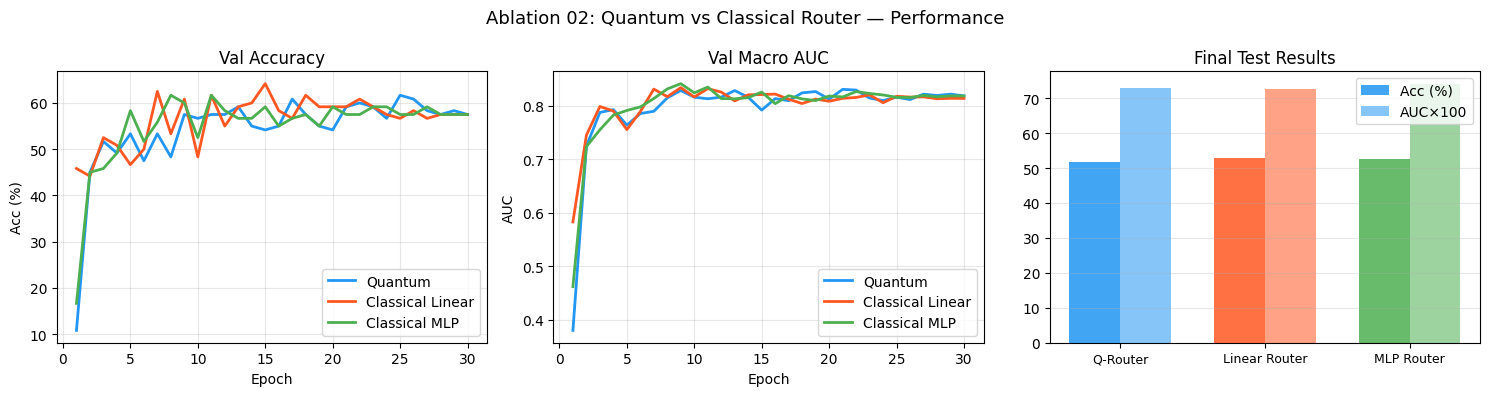

In [ ]:
names   = list(results.keys())
accs    = [results[n]["acc"]*100 for n in names]
aucs    = [results[n]["auc"]     for n in names]
colors  = ["#2196F3","#FF5722","#4CAF50"]

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, (hist_file, label) in enumerate([
    (f"{ABLATION_DIR}/hist_quantum_router.json",          "Quantum"),
    (f"{ABLATION_DIR}/hist_classical_linear_router.json", "Classical Linear"),
    (f"{ABLATION_DIR}/hist_classical_mlp_router.json",    "Classical MLP"),
]):
    with open(hist_file) as f: h = json.load(f)
    ep = range(1, len(h["val_acc"])+1)
    axes[0].plot(ep, [a*100 for a in h["val_acc"]], label=label, lw=2, color=colors[i])
    axes[1].plot(ep, h["val_auc"],                  label=label, lw=2, color=colors[i])

for ax, title, ylabel in [(axes[0],"Val Accuracy","Acc (%)"),(axes[1],"Val Macro AUC","AUC")]:
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

x = np.arange(len(names)); w = 0.35
ax2 = axes[2]
b1 = ax2.bar(x-w/2, accs,        width=w, color=colors, alpha=0.85, label="Acc (%)")
b2 = ax2.bar(x+w/2, [a*100 for a in aucs], width=w, color=colors, alpha=0.55, label="AUC×100")
ax2.set_xticks(x); ax2.set_xticklabels(["Q-Router","Linear Router","MLP Router"], fontsize=9)
ax2.set_title("Final Test Results"); ax2.legend(); ax2.grid(alpha=0.3,axis="y")

plt.suptitle("Ablation 02: Quantum vs Classical Router — Performance", fontsize=13)
plt.tight_layout()
plt.savefig(f"{ABLATION_DIR}/ablation02_results.png", dpi=150, bbox_inches="tight")
plt.show()
